# Backpropagation from Scratch

In the previous notebook, we built our first Artificial Neural Network and learned how information flows from the input layer to the output layer through a process called **Forward Propagation**.

Although our network could produce predictions, there was one major problem.

The weights of the network were initialized randomly.

As a result, the predictions were also random.

This raises an important question.

> **How does a Neural Network improve its predictions?**

The answer is **Backpropagation**.

Backpropagation is the algorithm that allows a Neural Network to learn from its mistakes.

Instead of guessing new weights randomly, the network measures how wrong its prediction was, calculates how each weight contributed to that error, and then adjusts every weight in the correct direction.

This process is repeated thousands of times until the network learns to make accurate predictions.

In this notebook, you'll learn:

- Why Neural Networks need Backpropagation
- How to measure prediction error
- What gradients are
- The intuition behind the Chain Rule
- How errors propagate backward through the network
- How weights are updated using Gradient Descent
- How to train a simple Neural Network using NumPy

In [27]:
import numpy as np

## Revisiting Our Neural Network

In the previous notebook, we built the following Neural Network.

```

Input Layer
(3 neurons)

↓

Hidden Layer
(2 neurons)

↓

Output Layer
(1 neuron)

```

During **Forward Propagation**, the network performed the following computations.

Hidden Layer

$$
Z_1 = XW_1 + b_1                                 

A_1 = \sigma(Z_1)                                   

Output Layer                                                    

Z_2 = A_1W_2 + b_2                                      

A_2 = \sigma(Z_2)                                               
$$

The value of \(A_2\) became the network's prediction.

However, the weights were initialized randomly.

Therefore, the prediction was also random.

The network had **no idea** whether its prediction was correct or incorrect.

To learn, it first needs a way to measure how good or bad its prediction is.

This brings us to the concept of a **Loss Function**.

## Revisiting Our Neural Network

In the previous notebook, we built the following Neural Network.

```

Input Layer
(3 neurons)

↓

Hidden Layer
(2 neurons)

↓

Output Layer
(1 neuron)

```

During **Forward Propagation**, the network performed the following computations.

Hidden Layer

$$
Z_1 = XW_1 + b_1


A_1 = \sigma(Z_1)

Output Layer

Z_2 = A_1W_2 + b_2

A_2 = \sigma(Z_2)
$$

The value of \(A_2\) became the network's prediction.

However, the weights were initialized randomly.

Therefore, the prediction was also random.

The network had **no idea** whether its prediction was correct or incorrect.

To learn, it first needs a way to measure how good or bad its prediction is.

This brings us to the concept of a **Loss Function**.

## How Does a Neural Network Learn?

Every Neural Network, regardless of its size, follows the same learning cycle.

```

Forward Propagation

↓

Prediction

↓

Loss Calculation

↓

Backpropagation

↓

Weight Update

↓

Repeat

```

Let's understand each step.

### 1. Forward Propagation

The input moves through the network to produce a prediction.

### 2. Loss Calculation

The prediction is compared with the correct answer.

The difference between them is called the **loss**.

### 3. Backpropagation

The network determines how much each weight contributed to the loss.

### 4. Weight Update

The weights are adjusted slightly so that the next prediction becomes better.

This cycle is repeated many times during training.

With every iteration, the network gradually improves its predictions.

## Learning from Mistakes

Imagine you're learning to throw a basketball into a hoop.

On your first attempt, the ball falls far short of the basket.

What do you do?

You don't throw the ball randomly again.

Instead, you make a small adjustment.

Perhaps you throw slightly harder.

If the next throw goes too far, you make another adjustment.

After many attempts, your throws become increasingly accurate.

A Neural Network learns in exactly the same way.

It makes a prediction.

If the prediction is wrong, it measures the error.

Then it makes a small adjustment to its weights before trying again.

Over thousands of iterations, these small adjustments accumulate, allowing the network to learn complex patterns from data.

Backpropagation is simply the mathematical method used to determine **what those adjustments should be**.

## Measuring the Error

Before a Neural Network can improve, it must first know **how good or bad its prediction is**.

Suppose the network predicts that a student will pass an exam with a probability of

\[
0.92
\]

If the student actually passed, this is a very good prediction.

Now suppose the network predicts

\[
0.08
\]

but the student actually passed.

This is clearly a poor prediction.

To improve its predictions, the network needs a way to measure the difference between:

- What it predicted
- What actually happened

This difference is called the **Loss**.

A loss of zero means the prediction is perfect.

A larger loss means the prediction is farther from the correct answer.

The goal of training is simple:

> **Find the weights that minimize the loss.**

## Binary Cross-Entropy Loss

In the Logistic Regression notebook, we introduced the Binary Cross-Entropy (BCE) Loss.

The same loss function is also commonly used for Neural Networks performing binary classification.

The Binary Cross-Entropy Loss is

$$
L =
-\left(
y\log(p)
+
(1-y)\log(1-p)
\right)
$$

where

- \(y\) is the actual class.
- \(p\) is the predicted probability.

This equation measures how close the predicted probability is to the correct answer.

A smaller loss indicates a better prediction.

During training, the Neural Network continuously adjusts its weights to reduce this loss.

In [28]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    return -(y_true * np.log(y_pred) +
             (1 - y_true) * np.log(1 - y_pred))

In [29]:
actual = 1

predictions = np.array([
    0.99,
    0.90,
    0.70,
    0.50,
    0.20,
    0.01
])

loss = binary_cross_entropy(actual, predictions)

print("Prediction\tLoss")
print("-" * 25)

for p, l in zip(predictions, loss):
    print(f"{p:.2f}\t\t{l:.4f}")

Prediction	Loss
-------------------------
0.99		0.0101
0.90		0.1054
0.70		0.3567
0.50		0.6931
0.20		1.6094
0.01		4.6052


## Interpreting the Loss

Notice how the loss changes.

When the network predicts

\[
0.99
\]

for the correct class, the loss is extremely small.

When the prediction moves farther away from the correct answer, the loss increases.

Finally, when the network is **very confident but completely wrong**, the loss becomes very large.

This behaviour is important.

We want the Neural Network to learn much more from large mistakes than from small ones.

The loss function provides exactly this information.

However, it still doesn't tell us **how to improve the weights**.

Knowing that the prediction is wrong is only half of the problem.

The next question is much more interesting.

> **Which weights caused the error, and by how much should each one change?**

## What Is a Gradient?

Imagine you're standing on a mountain covered in thick fog.

Your goal is to reach the lowest point in the valley.

The problem is that you can only see a few steps around you.

How do you decide which direction to walk?

One simple strategy is to look at the slope of the ground.

- If the ground slopes downward, walk in that direction.
- If the ground slopes upward, walk in the opposite direction.
- If the ground is completely flat, you've probably reached the bottom.

This idea is exactly what a **gradient** tells us.

A gradient describes how a quantity changes when we make a very small change to one of its inputs.

In Machine Learning, the quantity we care about is the **Loss**.

The inputs we want to change are the **weights** of the Neural Network.

Therefore, the gradient tells us:

> **"If I change this weight slightly, how will the loss change?"**

This information allows the Neural Network to improve its weights systematically instead of guessing randomly.

## Understanding the Gradient Intuitively

Suppose we slightly increase one weight in the Neural Network.

Two things can happen.

### Case 1

The loss decreases.

```
Weight ↑

↓

Loss ↓
```

This means increasing the weight improved the prediction.

So, during training, we should continue moving the weight in this direction.

---

### Case 2

The loss increases.

```
Weight ↑

↓

Loss ↑
```

This means increasing the weight made the prediction worse.

Instead, we should move the weight in the opposite direction.

The gradient tells us exactly which of these two situations is happening.

It also tells us **how strongly** the weight affects the loss.

Some weights require large adjustments.

Others require only tiny adjustments.

Backpropagation computes these gradients for every weight in the Neural Network.

## The Mathematical Definition of a Gradient

Mathematically, the gradient of the loss with respect to a weight is written as

$$\frac{\partial L}{\partial w}$$

This notation is read as:

> "The partial derivative of the loss with respect to the weight."

Don't worry if this notation looks unfamiliar.

For now, focus only on its meaning.

It answers one simple question:

> **If the weight changes by a tiny amount, how much will the loss change?**

The sign of the gradient tells us the direction.

- Positive gradient → Increasing the weight increases the loss.
- Negative gradient → Increasing the weight decreases the loss.

The magnitude of the gradient tells us how sensitive the loss is to that weight.

A large gradient means the weight has a strong influence on the loss.

A small gradient means the weight has only a small influence.

In [30]:
weight = 2.0

loss_values = []

for new_weight in [1.8, 1.9, 2.0, 2.1, 2.2]:

    loss = (new_weight - 3) ** 2

    loss_values.append((new_weight, loss))

print("Weight\tLoss")
print("-" * 20)

for w, l in loss_values:
    print(f"{w:.1f}\t{l:.2f}")

Weight	Loss
--------------------
1.8	1.44
1.9	1.21
2.0	1.00
2.1	0.81
2.2	0.64


## What Did We Observe?

Notice what happened.

As the weight increased,

```
1.8 → 1.9 → 2.0 → 2.1 → 2.2
```

the loss became smaller.

This tells us that increasing the weight moves us closer to the minimum loss.

If we continued this process, the smallest loss would occur when the weight reaches

\[
w = 3
\]

At this point, the gradient becomes zero because changing the weight in either direction would increase the loss.

This simple example illustrates the purpose of a gradient.

It tells us which direction moves us toward a smaller loss.

Backpropagation performs this same idea for every weight in a Neural Network, even when there are millions of them.

## Why Do We Need the Chain Rule?

So far, we've learned that the gradient tells us how changing a weight affects the loss.

But there is a problem.

A weight does **not** affect the loss directly.

Instead, the effect happens through several intermediate steps.

For example, consider the output layer of our Neural Network.

Changing a weight changes the weighted sum.

The weighted sum changes the activation.

The activation changes the prediction.

The prediction changes the loss.

The complete chain looks like this.

```

Weight

↓

Weighted Sum (Z)

↓

Activation (A)

↓

Loss (L)

```

Because the loss depends on the weight through several intermediate calculations, we cannot compute the gradient in a single step.

Instead, we must calculate how each step influences the next.

This is exactly what the **Chain Rule** allows us to do.

## Understanding the Chain Rule with an Everyday Example

Imagine you're making a cup of coffee.

The amount of coffee powder affects the strength of the coffee.

The strength of the coffee affects your energy level.

Your energy level affects how productive you are.

The chain looks like this.

```

Coffee Powder

↓

Coffee Strength

↓

Energy

↓

Productivity

```

Suppose someone asks:

> **"How does adding more coffee powder affect your productivity?"**

There is no direct connection.

Coffee powder first changes the coffee strength.

Coffee strength changes your energy.

Energy changes your productivity.

To understand the overall effect, we must combine the effect of every step in the chain.

Neural Networks work in exactly the same way.

A weight changes the weighted sum.

The weighted sum changes the activation.

The activation changes the loss.

The Chain Rule combines all of these small effects into one overall gradient.

## The Chain Rule

Mathematically, suppose the loss depends on the activation,

the activation depends on the weighted sum,

and the weighted sum depends on the weight.

The gradient of the loss with respect to the weight is

$$ \frac{\partial L}{\partial w} = \frac{\partial L}{\partial A} \cdot \frac{\partial A}{\partial Z} \cdot \frac{\partial Z}{\partial w} $$


This equation may look complicated at first.

However, it simply says:

> **Overall change = Effect of Step 1 × Effect of Step 2 × Effect of Step 3**

The Chain Rule allows us to compute the influence of a weight even when several intermediate calculations lie between the weight and the final loss.

## Applying the Chain Rule to a Neural Network

Consider a single neuron.

```

Input

↓

Weighted Sum

↓

Activation

↓

Loss

```

During **Forward Propagation**, information moves from top to bottom.

```

X

↓

Z

↓

A

↓

L

```

During **Backpropagation**, we move in the opposite direction.

```

L

↓

A

↓

Z

↓

Weights

```

At each step, we compute how much one value influences the previous value.

This is why the algorithm is called **Backpropagation**.

The error is propagated backward through the network so that every weight receives its own gradient.

## Why Backpropagation Is Efficient

Imagine a Neural Network containing one million weights.

One approach would be to slightly change each weight individually, measure the loss again, and repeat this process one million times.

Although this would work, it would be far too slow.

Backpropagation is much smarter.

By applying the Chain Rule, it computes the gradients of **all weights** in a single backward pass through the network.

This makes it possible to train Neural Networks containing millions or even billions of parameters.

Modern Deep Learning frameworks such as TensorFlow and PyTorch use this same idea internally.

## Deriving the Output Layer Gradient

Let's focus on the output neuron.

During Forward Propagation, the output neuron performs two computations.

First, it computes the weighted sum.

$$
Z_2 = A_1W_2 + b_2
$$

Then it applies the sigmoid activation function.

$$
A_2 = \sigma(Z_2)
$$

Finally, the prediction is compared with the true label using Binary Cross-Entropy Loss.

$$
L =
-\left(
y\log(A_2)
+
(1-y)\log(1-A_2)
\right)
$$

Notice the sequence of computations.

```

Weights (W₂)

↓

Weighted Sum (Z₂)

↓

Activation (A₂)

↓

Loss (L)

```

Since the loss depends on the weights through several intermediate steps, we apply the **Chain Rule**.

## Applying the Chain Rule

From the previous section, we know that

$$
\frac{\partial L}{\partial W_2}
=
\frac{\partial L}{\partial A_2}
\cdot
\frac{\partial A_2}{\partial Z_2}
\cdot
\frac{\partial Z_2}{\partial W_2}
$$

Instead of trying to calculate everything at once, we'll calculate each part separately.

1. How does the loss change with the activation?

2. How does the activation change with the weighted sum?

3. How does the weighted sum change with the weights?

Finally, we'll combine all three results.

Breaking the problem into smaller pieces is the main idea behind Backpropagation.

## Computing the Output Layer Gradients

Now that we know

$$
dZ_2 = A_2-y
$$

the remaining gradients are straightforward.

Weight Gradient

$$
dW_2=A_1^TdZ_2
$$

Bias Gradient

$$
db_2=\sum dZ_2
$$

These equations tell us exactly how much each parameter in the output layer contributed to the loss.

Once these gradients are known, Gradient Descent can update the weights and biases to reduce the loss.

In [31]:
# Example output

A2 = np.array([[0.82]])
Y = np.array([[1]])

# Output layer error

dZ2 = A2 - Y

print("dZ2")
print(dZ2)

dZ2
[[-0.18]]


## Interpreting the Output Error

Suppose

Prediction

$$
A_2=0.82
$$

Actual

$$
y=1
$$

Then

$$
dZ_2
=
A_2-y
=
-0.18
$$

The negative sign tells us that the network predicted a value that is **too small**.

During Gradient Descent, the weights will be adjusted so that the prediction increases on the next iteration.

If the prediction had been larger than the correct value, the gradient would be positive, causing the weights to move in the opposite direction.

This simple difference,

$$
A_2-y
$$

is the starting point of Backpropagation.

The error is then propagated backward through the hidden layers.

## The Hidden Layer Has a Different Problem

The output neuron is special.

It can compare its prediction directly with the correct answer.

For example,

Prediction

$$
A_2 = 0.82
$$

Actual

$$
y = 1
$$

From this, we can immediately compute the output error.

$$
dZ_2 = A_2 - y
$$

The hidden layer cannot do this.

Why?

Because hidden neurons do not know the correct answer.

They only produce intermediate values that help the output neuron make its prediction.

This raises an important question.

> **How can a hidden neuron know whether it contributed to the final error?**

## Propagating the Error Backward

Imagine working on a group project.

The final project receives a poor grade.

The teacher does not tell each student individually what they did wrong.

Instead, the feedback is given for the completed project.

Each student then examines how their own contribution affected the final result.

Neural Networks work in a similar way.

The output layer knows the final error.

The hidden layer estimates its own contribution to that error by looking at how strongly it influenced the output layer.

In other words,

the error is passed backward through the network.

This process is called **Backpropagation**.

## Hidden Layer Error

The hidden layer receives its error from the output layer.

Mathematically,

$$
dZ_1
=
(dZ_2W_2^T)
\odot
\sigma'(Z_1)
$$

Let's understand this equation piece by piece.

### Step 1

The output error

$$
dZ_2
$$

is passed backward through the weights

$$
W_2
$$

This tells us how much each hidden neuron contributed to the output error.

### Step 2

The result is multiplied by

$$
\sigma'(Z_1)
$$

which is the derivative of the activation function.

This adjusts the error according to how sensitive each hidden neuron is to changes in its input.

Together, these two steps compute the error for every hidden neuron.

## Why Do We Multiply by the Sigmoid Derivative?

Remember that the hidden neuron does not send its weighted sum directly to the next layer.

Instead, it sends

$$
A_1=\sigma(Z_1)
$$

The activation function changes the relationship between the weighted sum and the output.

Therefore, when computing gradients, we must account for this transformation.

For the sigmoid function,

$$
\sigma'(z)
=
\sigma(z)(1-\sigma(z))
$$

An important property of this derivative is that it is largest when the neuron is uncertain and becomes smaller as the neuron becomes saturated near 0 or 1.

This means neurons that are already producing extreme outputs tend to receive smaller gradient updates.

In [32]:
def sigmoid_derivative(a):
    return a * (1 - a)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [33]:
# Example values

A1 = np.array([[0.8, 0.3]])

print("Hidden Activations:")
print(A1)

print("\nSigmoid Derivative:")
print(sigmoid_derivative(A1))

Hidden Activations:
[[0.8 0.3]]

Sigmoid Derivative:
[[0.16 0.21]]


## Computing the Hidden Layer Gradients

Once we know the hidden layer error,

$$
dZ_1
$$

the remaining gradients follow the same pattern as the output layer.

Weight Gradient

$$
dW_1 = X^TdZ_1
$$

Bias Gradient

$$
db_1 = \sum dZ_1
$$

Notice something remarkable.

The equations for the hidden layer are almost identical to those for the output layer.

Every layer in a Neural Network follows the same pattern:

1. Compute the layer's error.
2. Compute the weight gradients.
3. Compute the bias gradients.

The only difference is how the layer's error is obtained.

The output layer compares its prediction with the true label.

Hidden layers receive their error from the layer in front of them.

## Implementing Backpropagation

We now have everything we need.

During one training iteration, the Neural Network performs the following steps.

```

Forward Propagation

↓

Compute Loss

↓

Compute Output Layer Error

↓

Compute Hidden Layer Error

↓

Compute Gradients

↓

Update Parameters

```

We'll now implement each of these steps using NumPy.

In [34]:
# Input
X = np.array([
    [8, 90, 85]
])

# Actual output
Y = np.array([
    [1]
])

In [35]:
np.random.seed(42)

W1 = np.random.randn(3,2)
b1 = np.zeros((1,2))

W2 = np.random.randn(2,1)
b2 = np.zeros((1,1))

In [36]:
# Hidden Layer

Z1 = X @ W1 + b1
A1 = sigmoid_derivative(Z1)

# Output Layer

Z2 = A1 @ W2 + b2
A2 = sigmoid_derivative(Z2)

In [37]:
loss = np.mean(binary_cross_entropy(Y, A2))

print(f"Loss: {loss:.6f}")

Loss: 34.538776


In [38]:
# Output layer error

dZ2 = A2 - Y

# Output gradients

dW2 = A1.T @ dZ2
db2 = np.sum(dZ2, axis=0, keepdims=True)

print("dW2")
print(dW2)

print("\ndb2")
print(db2)

dW2
[[2.96890135e+11]
 [2.26281163e+12]]

db2
[[-1.69435497e+08]]


In [39]:
dZ1 = (dZ2 @ W2.T) * sigmoid(A1)

dW1 = X.T @ dZ1
db1 = np.sum(dZ1, axis=0, keepdims=True)

print("dW1")
print(dW1)

print("\ndb1")
print(db1)

dW1
[[0. 0.]
 [0. 0.]
 [0. 0.]]

db1
[[0. 0.]]


/tmp/ipykernel_11238/241081899.py:5: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


## Updating the Parameters

Once the gradients have been computed, we update every parameter using Gradient Descent.

For every weight,

$$
W=W-\alpha dW
$$

For every bias,

$$
b=b-\alpha db
$$

where

- \(W\) is the weight matrix
- \(b\) is the bias vector
- \(\alpha\) is the learning rate

This update moves every parameter in the direction that reduces the loss.

## Updating the Parameters

Once the gradients have been computed, we update every parameter using Gradient Descent.

For every weight,

$$
W=W-\alpha dW
$$

For every bias,

$$
b=b-\alpha db
$$

where

- W is the weight matrix
- b is the bias vector
- alpha is the learning rate

This update moves every parameter in the direction that reduces the loss.

In [42]:
np.random.seed(42)

W1 = np.random.randn(3,2)
b1 = np.zeros((1,2))

W2 = np.random.randn(2,1)
b2 = np.zeros((1,1))

learning_rate = 0.01
epochs = 10000

loss_history = []

for epoch in range(epochs):

    # Forward
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)

    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    # Loss
    loss = np.mean(binary_cross_entropy(Y, A2))
    loss_history.append(loss)

    # Backpropagation
    dZ2 = A2 - Y
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dZ1 = (dZ2 @ W2.T) * sigmoid_derivative(A1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss:.6f}")

Epoch    0 | Loss = 0.091384
Epoch  100 | Loss = 0.072925
Epoch  200 | Loss = 0.060519
Epoch  300 | Loss = 0.051643
Epoch  400 | Loss = 0.044994
Epoch  500 | Loss = 0.039836
Epoch  600 | Loss = 0.035722
Epoch  700 | Loss = 0.032367
Epoch  800 | Loss = 0.029581
Epoch  900 | Loss = 0.027231
Epoch 1000 | Loss = 0.025223
Epoch 1100 | Loss = 0.023488
Epoch 1200 | Loss = 0.021974
Epoch 1300 | Loss = 0.020641
Epoch 1400 | Loss = 0.019460
Epoch 1500 | Loss = 0.018405
Epoch 1600 | Loss = 0.017458
Epoch 1700 | Loss = 0.016603
Epoch 1800 | Loss = 0.015827
Epoch 1900 | Loss = 0.015120
Epoch 2000 | Loss = 0.014473
Epoch 2100 | Loss = 0.013879
Epoch 2200 | Loss = 0.013331
Epoch 2300 | Loss = 0.012825
Epoch 2400 | Loss = 0.012355
Epoch 2500 | Loss = 0.011919
Epoch 2600 | Loss = 0.011512
Epoch 2700 | Loss = 0.011132
Epoch 2800 | Loss = 0.010776
Epoch 2900 | Loss = 0.010442
Epoch 3000 | Loss = 0.010127
Epoch 3100 | Loss = 0.009832
Epoch 3200 | Loss = 0.009553
Epoch 3300 | Loss = 0.009289
Epoch 3400 | L

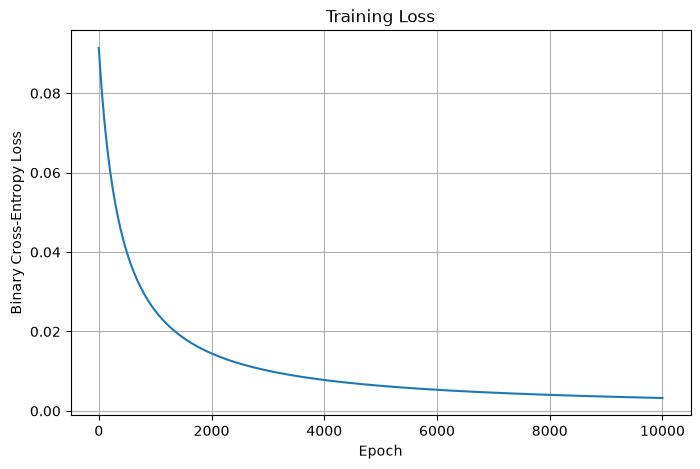

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_history)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.grid(True)
plt.show()

# Conclusion

Congratulations!

You have now implemented **Backpropagation** from scratch using only NumPy.

In this notebook, you learned:

- Why Neural Networks need Backpropagation.
- How Binary Cross-Entropy measures prediction error.
- What gradients represent.
- Why the Chain Rule is necessary.
- How errors propagate backward through the network.
- How to compute gradients for both the output and hidden layers.
- How Gradient Descent updates weights and biases.
- How repeated training reduces the loss over time.

Backpropagation is one of the fundamental algorithms in Machine Learning.

Although modern frameworks such as TensorFlow and PyTorch compute gradients automatically, they rely on the same mathematical principles introduced in this notebook.